### Imports and settings

In [ ]:
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
from pathlib import Path
import colorcet as cc
import calendar
from scipy import stats
from importlib import reload
import dyndowntools.util as du

In [ ]:
reload(du)

<module 'dyndowntools.util' from '/Users/chris/Projects/dyndowntools/dyndowntools/util.py'>

In [ ]:
datadir = Path().absolute().parent / "evaluation/working"
figdir = Path().absolute().parent / "evaluation/figures"
stationdir = Path().absolute().parent / "evaluation/weatherstationdata/ACIS"
filepattern_ERA5 = 't2m_{agg}_{airport}_1981_2020_{resolution}.csv'
filepattern_station = "{station}_T_max_min_avg_pcpn_sd_swe.csv"

In [ ]:
stations = {
    "ANCHORAGE_TED_STEVENS_INTERNATIONAL_AIRPORT": "ANC_PANC",
    "FAIRBANKS_INTL_AP": "FAI_PAFA",
    "BARROW_AIRPORT": "UTQ_PABR",
    "BETHEL_AIRPORT": "BTH_PABE"
}
startdate = '1981-01-01'
enddate = '2020-12-31'
agg = 'max'
fullnames = list(stations.keys())
resolutions = ['4km', '12km']
teststation = 'BETHEL_AIRPORT'

In [ ]:
month_abbr = [calendar.month_abbr[ii] for ii in range(1, 13)]
month_initials = [item[0] for item in month_abbr]

### Functions

In [ ]:
def F2C(temp_F):
    return (temp_F - 32.0) * 5.0/9.0

In [ ]:
def get_dataframe_ERA5(station, startdate=startdate, enddate=enddate):
    dfs = {}
    var = f'T2_{agg}'
    for res in resolutions:
        dfs[res] = pd.read_csv(
            datadir / filepattern_ERA5.format(airport=stations[station], agg=agg, resolution=res))
        dfs[res]['Time'] = pd.to_datetime(dfs[res]['Time'])
        dfs[res][var] = dfs[res][var] - 273.15      # K to C
        dfs[res].rename(columns={var: f"{var}_{res}"}, inplace=True)
        # dfs[res].set_index('Time')
    dfs['4km'][f'{var}_12km'] = dfs['12km'][f'{var}_12km']
    return dfs['4km']

def get_dataframe_station(station, startdate=startdate, enddate=enddate):
    stationpth = stationdir / filepattern_station.format(station=station)
    df = du.station2df(stationpth)
    # return df
    if agg=='max':
        df['Tmax_C'] = F2C(df['Tmax_F'].astype(float))
        return df['Tmax_C'].loc[startdate:enddate]
    elif agg=='mean':
        df['Tavg_C'] = F2C(df['Tavg_F'])
        return df['Tavg_C'].loc[startdate:enddate]
    return df.loc[startdate:enddate]

def get_dataframe(station, startdate=startdate, enddate=enddate):
    ERA5df = get_dataframe_ERA5(station, startdate=startdate, enddate=enddate)
    stationdf = get_dataframe_station(station, startdate=startdate, enddate=enddate)
    ERA5df.set_index('Time', inplace=True)
    ERA5df.index = pd.to_datetime(ERA5df.index)
    stationdf.index.name = 'Time'
    stationdf.index = pd.to_datetime(stationdf.index)

    return pd.merge(ERA5df, stationdf,
            how='inner', left_index=True, right_index=True)

In [ ]:
def get_stats(teststation, monthlyDF):
    output = []
    for variable in ('ws', 'wspd10_4km', 'wspd10_12km'):
        for mth in range(1, 13):
            X = monthlyDF.query(f'month == {mth}')['year']
            Y = monthlyDF.query(f'month == {mth}')[variable]
            slope, _, r_value, p_value, _ = stats.linregress(X, Y)
            mean = Y.mean()
            output.append({
                "location": stations[teststation],
                'variable': variable,
                'month': mth, 
                'mean_monthly_wspd': mean, 
                'trend': slope, 
                'p_value': p_value, 
                'r_value':r_value})
    return output

In [ ]:
def get_monthly(dailyDF):
    # dailyDF = dailyDF.loc[startdate:enddate]
    monthly_avg = dailyDF[['T2_max_4km', 'T2_max_12km', 'Tmax_C']].groupby(
        pd.Grouper(freq='M')).mean()
    monthly_avg['year'] = monthly_avg.index.year
    monthly_avg['month'] = monthly_avg.index.month
    return monthly_avg

In [ ]:
def get_name(location):
    name = location.split(' ')[0].title()
    if name == 'Barrow':
        return 'Utqiaġvik'
    else:
        return name

In [ ]:
def add_significance_suffix(p_value):
    if p_value < 0.05:
        return ' (**)'
    elif p_value < 0.1:
        return ' (*)'
    else: return ''

### Single location prototyping

In [ ]:
get_dataframe(teststation)

,T2_max_4km,T2_max_12km,Tmax_C
Time,,,
1981-01-01,1.189,1.268,1.666667
1981-01-02,0.642,0.797,-2.777778
1981-01-03,-1.294,-0.788,-2.777778
1981-01-04,1.530,1.054,2.222222
1981-01-05,1.479,1.543,2.222222
...,...,...,...
2020-12-27,1.585,1.656,2.777778
2020-12-28,1.303,1.432,2.777778
2020-12-29,1.834,1.821,2.777778


In [ ]:
stationpth = stationdir / filepattern_station.format(station=teststation)
df = du.station2df(stationpth)
df

,Tmax_F,Tmin_F,Tavg_F,precip_in,sd_m,swe,year
1951-01-02,12.0,3.0,7.5,0.01,4,-9999,1951
1951-01-03,8.0,2.0,5.0,0.01,4,-9999,1951
1951-01-04,14.0,8.0,11.0,0.00,4,-9999,1951
1951-01-05,32.0,9.0,20.5,0.37,5,-9999,1951
1951-01-06,32.0,27.0,29.5,0.13,8,-9999,1951
...,...,...,...,...,...,...,...
2020-12-27,37.0,16.0,26.5,0.01,-9999,-9999,2020
2020-12-28,37.0,25.0,31.0,0.01,-9999,-9999,2020
2020-12-29,37.0,22.0,29.5,0.00,-9999,-9999,2020
2020-12-30,28.0,12.0,20.0,0.00,-9999,-9999,2020


In [ ]:
compDF = get_dataframe(teststation)
monthly_DF = get_monthly(compDF)
monthly_DF

/var/folders/jh/dmrl1jcn7ql6ftcyq7l6p8v80000gn/T/ipykernel_8411/2578701553.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  pd.Grouper(freq='M')).mean()


,T2_max_4km,T2_max_12km,Tmax_C,year,month
Time,,,,,
1981-01-31,-2.852452,-2.814806,-2.903226,1981,1
1981-02-28,-9.691107,-9.617143,-7.222222,1981,2
1981-03-31,-0.467839,-0.348903,2.043011,1981,3
1981-04-30,0.042533,0.583800,4.111111,1981,4
1981-05-31,12.857000,13.024548,14.408602,1981,5
...,...,...,...,...,...
2020-08-31,17.227839,17.464742,17.759857,2020,8
2020-09-30,10.416700,10.587667,11.351852,2020,9
2020-10-31,4.443935,4.534806,5.322581,2020,10


In [ ]:
get_stats(teststation, monthly_DF)

NameError: name 'get_stats' is not defined

In [ ]:
output = []
for mth in range(1, 13):
    X = monthly_sum.query(f'month == {mth}')['year']
    Y = monthly_sum.query(f'month == {mth}')[location]
    slope, intercept, r_value, p_value, std_err = stats.linregress(X, Y)
    mean = Y.mean()
    output.append((mth, mean, slope, p_value, r_value, std_err))

NameError: name 'monthly_sum' is not defined

In [ ]:
mth = 8
X = monthly_DF.query(f'month == {mth}')['year']
Y = monthly_DF.query(f'month == {mth}')['ws']
slope, intercept, r_value, p_value, std_err = stats.linregress(X, Y)

In [ ]:
slope, intercept, p_value

(-0.00568650989229438, 19.538096555022225, 0.6053087018272245)

In [ ]:
cmap = plt.cm.get_cmap('cet_glasbey')
cmap = plt.cm.get_cmap('Set1')

/var/folders/jh/dmrl1jcn7ql6ftcyq7l6p8v80000gn/T/ipykernel_3995/1137458020.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('cet_glasbey')
/var/folders/jh/dmrl1jcn7ql6ftcyq7l6p8v80000gn/T/ipykernel_3995/1137458020.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('Set1')


In [ ]:
# monthly_DF.index.name = 'Time'
df_forplot = pd.melt(monthly_DF.reset_index(), id_vars=[monthly_DF.index.name, 'year', 'month'], 
        value_vars=['T2_max_4km', 'T2_max_12km', 'Tmax_C'], value_name='maxT', var_name=teststation)

In [ ]:
palette = sns.color_palette(cc.b_glasbey_category10, n_colors=3)
palette = sns.color_palette("Set2", 3)
viridis_palette = sns.color_palette("viridis", 25)
viridis_palette = [viridis_palette[ii] for ii in [14, 8, -1]]
viridis_palette

[(0.123444, 0.636809, 0.528763),
 (0.185556, 0.41857, 0.556753),
 (0.906311, 0.894855, 0.098125)]

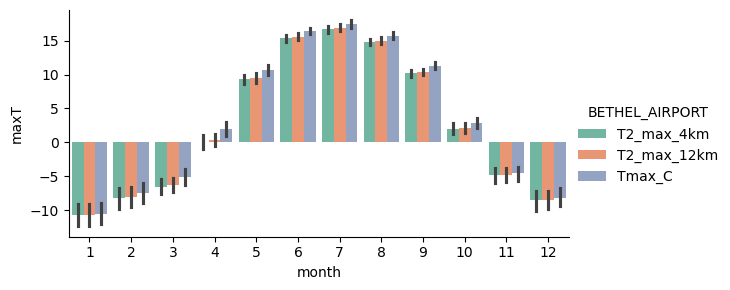

In [ ]:
g = sns.catplot(data=df_forplot, kind="bar", x="month", y="maxT", 
            hue=teststation, palette='Set2', width=0.85, height=3, aspect=2)
# g._legend.remove()

/var/folders/jh/dmrl1jcn7ql6ftcyq7l6p8v80000gn/T/ipykernel_8411/1696983467.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g.set_xticklabels(month_abbr)


Text(0.5, 1.0, 'BETHEL_AIRPORT')

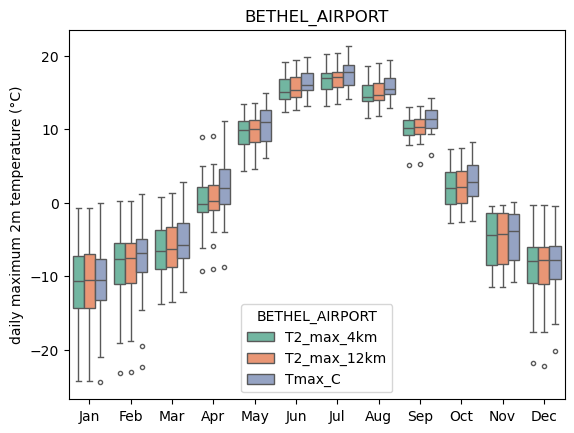

In [ ]:
g = sns.boxplot(data=df_forplot, x="month", y="maxT", 
            hue=teststation, palette='Set2', legend=True, fliersize=3)
g.set_xticklabels(month_abbr)
g.set_xlabel('')
g.set_ylabel('daily maximum 2m temperature (°C)')
g.set_title(teststation)

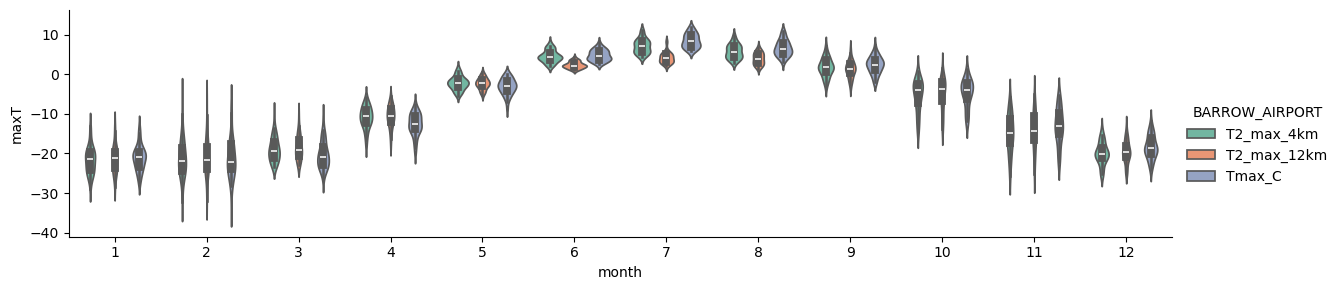

In [ ]:
g = sns.catplot(data=df_forplot, kind="violin", x="month", y="maxT", 
            hue=teststation, palette=palette, height=3, aspect=4)


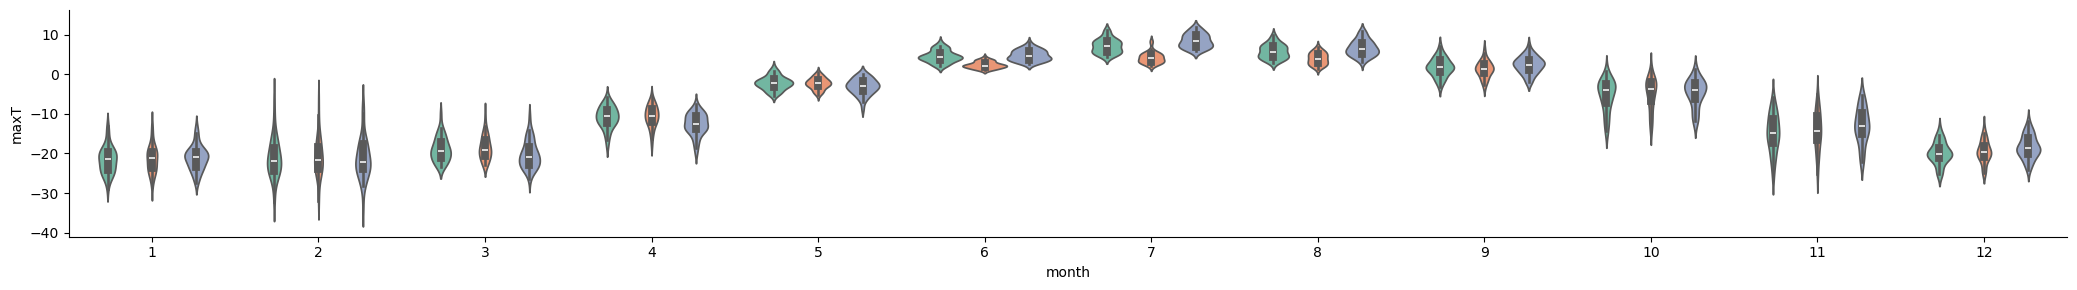

In [ ]:
g = sns.catplot(data=df_forplot, kind="violin", x="month", y="maxT", 
            hue=teststation, palette=palette, height=3, aspect=7)
g._legend.remove()

<Axes: xlabel='Time'>

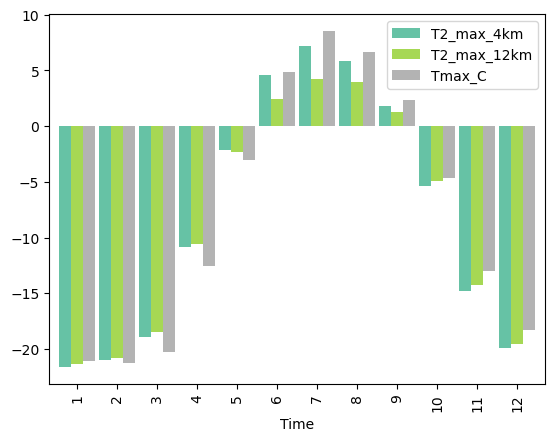

In [ ]:
monthly_DF.drop(columns=['month', 'year']).groupby(monthly_DF.index.month).mean().plot(
    kind='bar', width=0.9, cmap='Set2')

### Make all plots and statistics

/var/folders/jh/dmrl1jcn7ql6ftcyq7l6p8v80000gn/T/ipykernel_8411/2578701553.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  pd.Grouper(freq='M')).mean()
/var/folders/jh/dmrl1jcn7ql6ftcyq7l6p8v80000gn/T/ipykernel_8411/1534936620.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g.set_xticklabels(month_abbr)
/var/folders/jh/dmrl1jcn7ql6ftcyq7l6p8v80000gn/T/ipykernel_8411/2578701553.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  pd.Grouper(freq='M')).mean()
/var/folders/jh/dmrl1jcn7ql6ftcyq7l6p8v80000gn/T/ipykernel_8411/1534936620.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g.set_xticklabels(month_abbr)
/var/folders/jh/dmrl1jcn7ql6ftcyq7l6p8v80000gn/T/ipykernel_8411/2578701553.py:4: FutureWarning

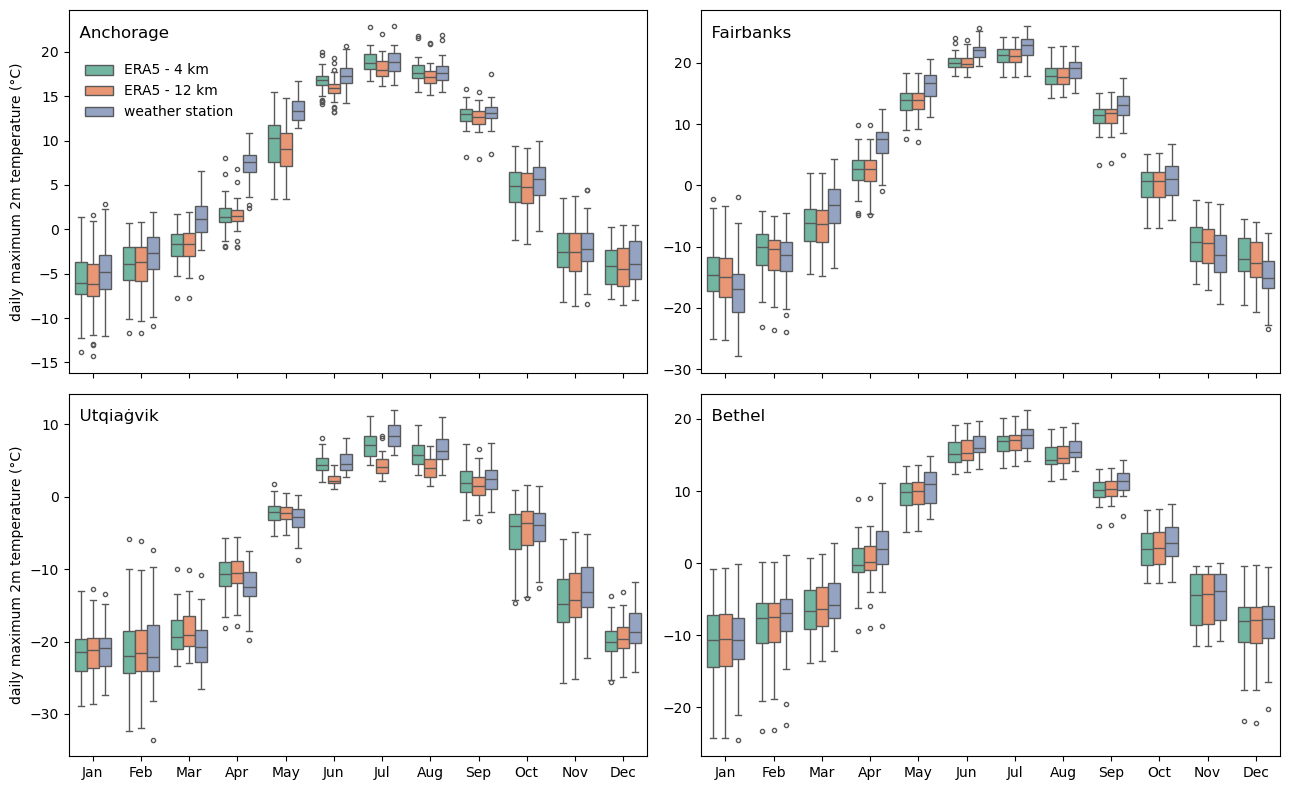

In [ ]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(13, 8), sharex=True)

results = []
for ii, (ax, station) in enumerate(zip(axes.flatten(), stations)):
    compDF = get_dataframe(station)
    locationname = get_name(station.replace('_', ' '))
    monthly_DF = get_monthly(compDF)
    monthly_DF.index.name = 'Time'
    # results.extend(get_stats(station, monthly_DF))
    df_forplot = pd.melt(monthly_DF.reset_index(), id_vars=[monthly_DF.index.name, 'year', 'month'], 
        value_vars=['T2_max_4km', 'T2_max_12km', 'Tmax_C'], value_name='maxT', var_name=station)
    g = sns.boxplot(data=df_forplot, x="month", y="maxT", 
            hue=station, palette="Set2", width=0.75, fliersize=3, ax=ax)
    ax.get_legend().remove()  
    g.set_xticklabels(month_abbr)
    g.set_xlabel('')
    if ii%2:
        g.set_ylabel('')
    else:
        g.set_ylabel('daily maximum 2m temperature (°C)')
    ax.set_title('  ' + locationname, loc='left', y=0.9)
handles, _ = ax.get_legend_handles_labels()
labels = ['ERA5 - 4 km', 'ERA5 - 12 km', 'weather station']
fig.legend(handles, labels, loc='upper left', ncol=1, bbox_to_anchor=(0.06, 0.93), frameon=False)
plt.tight_layout()

In [ ]:
fn = f"tmax_stations_monthly_distribution_box_{startdate}-{enddate}.png"
fig.savefig(figdir / fn, bbox_inches='tight', dpi=300)

In [ ]:
results = []
for station in stations:
    compDF = get_dataframe(station)
    location = locations[station]
    monthly_DF = get_monthly(compDF, 
                        startdate=startdate, enddate=enddate)
    monthly_DF.index.name = 'Time'
    results.extend(get_stats(station, monthly_DF))

/var/folders/jh/dmrl1jcn7ql6ftcyq7l6p8v80000gn/T/ipykernel_3995/1654113850.py:6: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  pd.Grouper(freq='M')).mean()
/var/folders/jh/dmrl1jcn7ql6ftcyq7l6p8v80000gn/T/ipykernel_3995/1654113850.py:6: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  pd.Grouper(freq='M')).mean()
/var/folders/jh/dmrl1jcn7ql6ftcyq7l6p8v80000gn/T/ipykernel_3995/1654113850.py:6: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  pd.Grouper(freq='M')).mean()
/var/folders/jh/dmrl1jcn7ql6ftcyq7l6p8v80000gn/T/ipykernel_3995/1654113850.py:6: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  pd.Grouper(freq='M')).mean()


In [ ]:
resultsDF = pd.DataFrame.from_records(results)
resultsDF

,location,variable,month,mean_monthly_wspd,trend,p_value,r_value
0,PANC,ws,1,5.579380,-0.039072,0.000065,-0.588398
1,PANC,ws,2,5.712088,-0.046223,0.000171,-0.560154
2,PANC,ws,3,5.892847,-0.014684,0.175383,-0.218591
3,PANC,ws,4,6.134023,-0.014286,0.124031,-0.247237
4,PANC,ws,5,6.836781,-0.002189,0.811044,-0.039025
...,...,...,...,...,...,...,...
139,PABE,wspd10_12km,8,6.322330,-0.012712,0.213657,-0.200986
140,PABE,wspd10_12km,9,6.949668,-0.015849,0.168385,-0.222099
141,PABE,wspd10_12km,10,7.353198,0.009873,0.388272,0.140183
142,PABE,wspd10_12km,11,7.911085,0.002700,0.855340,0.029763


In [ ]:
tableDF = resultsDF.query('variable != "ERA5-12km"')
tableDF['ID'] = tableDF.location + ': ' + tableDF['variable']
tableDF['strtrend'] = tableDF['trend'].round(2).astype(str) 
tableDF['sigtrend'] = tableDF['strtrend'] + tableDF['p_value'].apply(add_significance_suffix)


In [ ]:
sigtable = tableDF.pivot(index='ID', columns='month', values='sigtrend')
sigtable.columns = [calendar.month_abbr[ii] for ii in sigtable.columns]
sigtable

,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
ID,,,,,,,,,,,,
PABE: ws,0.01,0.0,-0.02 (*),0.0,0.01,-0.0,0.01,0.0,-0.0,-0.0,0.0,0.0
PABE: wspd10_12km,-0.0,0.02,-0.02 (**),0.01,-0.0,-0.0,-0.0,-0.01,-0.02,0.01,0.0,-0.02
PABE: wspd10_4km,-0.01,0.01,-0.02 (**),0.0,-0.0,-0.0,-0.0,-0.01,-0.02,0.01,0.0,-0.02
PABR: ws,0.02,0.04 (**),0.01,0.01,-0.0,0.01,0.0,-0.01,-0.01,0.04 (**),0.05 (**),0.02
PABR: wspd10_12km,-0.01,0.02,0.01,0.01,-0.01,0.01,0.01 (*),0.01,-0.0,0.05 (**),0.01,-0.01
PABR: wspd10_4km,-0.0,0.02,0.01,0.01,-0.0,0.01,0.0,0.0,-0.01,0.03 (**),0.0,-0.01
PAFA: ws,-0.0,-0.0,-0.0,0.0,-0.02 (**),-0.02 (**),-0.02 (**),-0.02 (**),-0.02 (**),-0.01 (*),0.0,0.01
PAFA: wspd10_12km,-0.01,-0.0,-0.01,0.01,-0.0,-0.0,-0.0,-0.01 (*),-0.01,-0.0,0.0,-0.0
PAFA: wspd10_4km,-0.01,-0.0,-0.0,0.01,0.0,-0.0,-0.0,-0.01 (*),-0.0,-0.0,0.0,0.0
